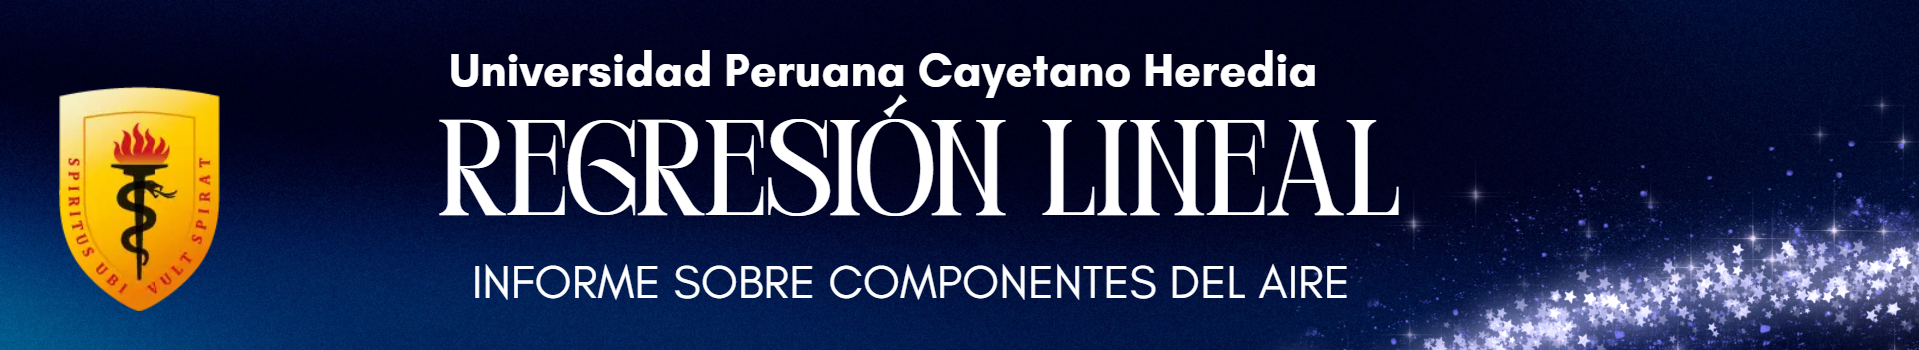

# Universidad peruana Cayetano Heredia

## Facultad de Ciencias e Ingeniería

## Profesores: 
Lewis De la Cruz
Renzo Chan

## Estudiante: 
Brigitte Bernal Belisario

# 2026

# 1. Introducción
 La calidad del aire es un factor crítico para la salud pública y el equilibrio ambiental. En Puerto Rico, factores geográficos y climáticos (como los polvos del Sahara y la actividad industrial) influyen en la variabilidad del Índice de Calidad del Aire (AQI). 

## 1.1 Objetivo:
El presente estudio busca analizar el comportamiento histórico del AQI y la concentración de Monóxido de Carbono (CO) entre los años 2022 y 2024, con el fin de desarrollar un modelo de Regresión Lineal capaz de proyectar la tendencia de la calidad del aire para el año 2025.

# 2. Metodología

La presente investigación emplea un enfoque cuantitativo y descriptivo para analizar la evolución de la calidad del aire (AQI) en Puerto Rico, mediante la extracción de datasets de la Agencia de Protección Ambiental de EE. UU. (EPA)[1], abarcando mediciones diarias de estaciones de monitoreo en Puerto Rico.
 El proceso se dividió en cuatro fases:

Adquisición y Limpieza de Datos: Se utilizaron registros diarios de la EPA (2022-2025). Se realizó un preprocesamiento para manejar valores nulos y se transformaron las fechas a formato ordinal para permitir el cálculo de regresiones.

Tratamiento de la Volatilidad: Debido a la alta variabilidad de los datos ambientales, se implementó una técnica de Suavizado Mensual mediante un promedio móvil de 30 días. Esto permitió separar el "ruido" (picos diarios) de la "señal" (tendencia real).

Modelado Estadístico: * Se aplicó una Regresión Lineal Simple para identificar la dirección de la tendencia a largo plazo.

Se implementó un modelo de Series de Tiempo (Prophet) para capturar componentes estacionales anuales.

Protocolo de Validación: Para garantizar la robustez del modelo, se utilizó Validación Cruzada Temporal (TimeSeriesSplit) con 5 pliegues (folds), evitando el sesgo de información futura y asegurando que el error reportado sea representativo de la capacidad predictiva real.



# 2.1. Adquisición y limpieza de datos


# Importamos librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Primeros datasets

In [2]:
pr2022 = pd.read_csv('/kaggle/input/datasets/brigitteadhar49/puerto-rico-componentes-aire/pr2022.csv')
pr2023 = pd.read_csv('/kaggle/input/datasets/brigitteadhar49/puerto-rico-componentes-aire/pr2023.csv')
pr2024 = pd.read_csv('/kaggle/input/datasets/brigitteadhar49/puerto-rico-componentes-aire/pr2024.csv')


In [3]:
# 2. Revisar las primeras filas para entender la estructura
print("Primeras filas:")
print(pr2022.head())
print(pr2023.head())
print(pr2024.head())

Primeras filas:
         Date Source    Site ID  POC  Daily Max 8-hour CO Concentration Units  \
0  01/01/2022    AQS  720210010    1                                0.2   ppm   
1  01/02/2022    AQS  720210010    1                                0.2   ppm   
2  01/03/2022    AQS  720210010    1                                0.2   ppm   
3  01/04/2022    AQS  720210010    1                                0.3   ppm   
4  01/05/2022    AQS  720210010    1                                0.2   ppm   

   Daily AQI Value Local Site Name  Daily Obs Count  Percent Complete  ...  \
0                2         Bayamon               19              79.0  ...   
1                2         Bayamon               24             100.0  ...   
2                2         Bayamon               24             100.0  ...   
3                3         Bayamon               24             100.0  ...   
4                2         Bayamon               24             100.0  ...   

   AQS Parameter Description

In [4]:
# 3. Ver información general (tipos de datos, valores nulos)
print("\nInformación del DataFrame Pr2022:")
print(pr2022.info())
print("\nInformación del DataFrame Pr2023:")
print(pr2023.info())
print("\nInformación del DataFrame Pr2024:")
print(pr2024.info())


Información del DataFrame Pr2022:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               863 non-null    object 
 1   Source                             863 non-null    object 
 2   Site ID                            863 non-null    int64  
 3   POC                                863 non-null    int64  
 4   Daily Max 8-hour CO Concentration  863 non-null    float64
 5   Units                              863 non-null    object 
 6   Daily AQI Value                    863 non-null    int64  
 7   Local Site Name                    570 non-null    object 
 8   Daily Obs Count                    863 non-null    int64  
 9   Percent Complete                   863 non-null    float64
 10  AQS Parameter Code                 863 non-null    int64  
 11  AQS Parameter Descripti

In [5]:
# 4. Estadísticas descriptivas básicas
print("\nEstadísticas descriptivas 2022:")
print(pr2022.describe())
print("\nEstadísticas descriptivas 2023:")
print(pr2023.describe())
print("\nEstadísticas descriptivas 2024:")
print(pr2024.describe())


Estadísticas descriptivas 2022:
            Site ID    POC  Daily Max 8-hour CO Concentration  \
count  8.630000e+02  863.0                         863.000000   
mean   7.204549e+08    1.0                           0.314600   
std    3.918712e+05    0.0                           0.317429   
min    7.202100e+08    1.0                          -0.400000   
25%    7.202100e+08    1.0                           0.100000   
50%    7.202500e+08    1.0                           0.200000   
75%    7.211300e+08    1.0                           0.500000   
max    7.211300e+08    1.0                           2.400000   

       Daily AQI Value  Daily Obs Count  Percent Complete  AQS Parameter Code  \
count       863.000000       863.000000        863.000000               863.0   
mean          3.687138        23.105446         96.280417             42101.0   
std           3.544796         3.322462         13.827330                 0.0   
min           0.000000         1.000000          4.000000

In [6]:
# 5. Verificar si hay valores faltantes
print("\nValores nulos por columna 2022:")
print(pr2022.isnull().sum())
# 5. Verificar si hay valores faltantes
print("\nValores nulos por columna 2023:")
print(pr2023.isnull().sum())
# 5. Verificar si hay valores faltantes
print("\nValores nulos por columna 2024:")
print(pr2024.isnull().sum())


Valores nulos por columna 2022:
Date                                   0
Source                                 0
Site ID                                0
POC                                    0
Daily Max 8-hour CO Concentration      0
Units                                  0
Daily AQI Value                        0
Local Site Name                      293
Daily Obs Count                        0
Percent Complete                       0
AQS Parameter Code                     0
AQS Parameter Description              0
Method Code                            0
CBSA Code                              0
CBSA Name                              0
State FIPS Code                        0
State                                  0
County FIPS Code                       0
County                                 0
Site Latitude                          0
Site Longitude                         0
dtype: int64

Valores nulos por columna 2023:
Date                                   0
Source             

In [7]:
# Concatenar los tres años en un solo DataFrame
df_total = pd.concat([pr2022, pr2023, pr2024], ignore_index=True)

# Convertir fecha a datetime
df_total['Date'] = pd.to_datetime(df_total['Date'])

# Limpiar concentraciones negativas (convertir a 0 o eliminar)
df_total = df_total[df_total['Daily Max 8-hour CO Concentration'] >= 0]

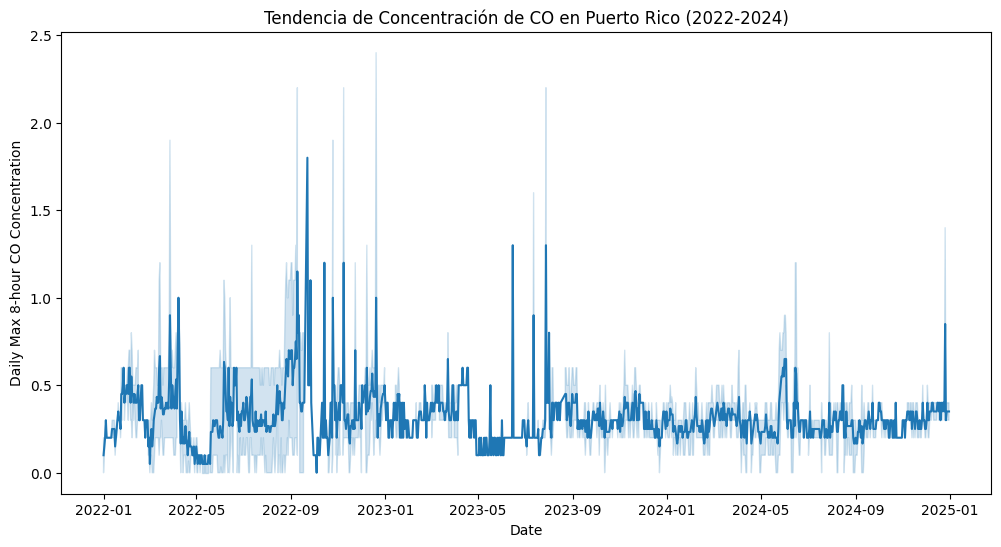

In [8]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_total, x='Date', y='Daily Max 8-hour CO Concentration')
plt.title('Tendencia de Concentración de CO en Puerto Rico (2022-2024)')
plt.show()

In [9]:
# Contar cuántos errores hay antes de borrar
print(f"Valores negativos detectados: {(df_total['Daily Max 8-hour CO Concentration'] < 0).sum()}")

# Mantener solo valores >= 0
df_total = df_total[df_total['Daily Max 8-hour CO Concentration'] >= 0]

Valores negativos detectados: 0


In [10]:
# Crear un diccionario de mapeo ID -> Nombre (usando filas que sí tienen nombre)
mapeo_nombres = df_total.dropna(subset=['Local Site Name']).drop_duplicates('Site ID')
diccionario_sitios = dict(zip(mapeo_nombres['Site ID'], mapeo_nombres['Local Site Name']))

# Rellenar los nulos en la columna original usando el mapa
df_total['Local Site Name'] = df_total['Local Site Name'].fillna(df_total['Site ID'].map(diccionario_sitios))

# Verificar si aún quedan nulos (en caso de que algún Site ID nunca tuviera nombre)
print(f"Nulos restantes en Local Site Name: {df_total['Local Site Name'].isnull().sum()}")

Nulos restantes en Local Site Name: 835


In [11]:
# Opción A: Rellenar con el County (Condado) para que al menos sepas la zona
#df_total['Local Site Name'] = df_total['Local Site Name'].fillna(df_total['County'])

# Opción B: Si prefieres mantener la distinción por estación exacta:
# Rellenar con 'Station_' + el número de ID
df_total['Local Site Name'] = df_total['Local Site Name'].fillna('Station_' + df_total['Site ID'].astype(str))

# Verificamos de nuevo
print(f"Nulos finales en Local Site Name: {df_total['Local Site Name'].isnull().sum()}")

Nulos finales en Local Site Name: 0


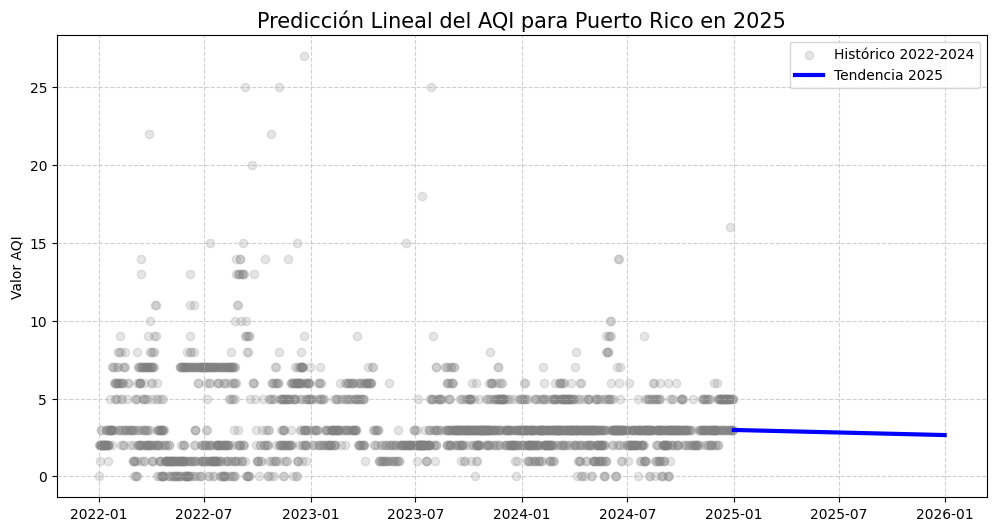

AQI promedio esperado para inicios de 2025: 2.98
AQI promedio esperado para finales de 2025: 2.65


In [12]:
import datetime as dt

# 1. Preparar la variable X (Tiempo)
# Convertimos las fechas a números ordinales para que la regresión pueda operar
df_total['Date_Ordinal'] = df_total['Date'].map(dt.datetime.toordinal)

X = df_total[['Date_Ordinal']]
y = df_total['Daily AQI Value']

# 2. Entrenar el modelo
model = LinearRegression()
model.fit(X, y)

# 3. Crear el futuro: Enero a Diciembre 2025
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
future_df = pd.DataFrame({'Date': future_dates})
future_df['Date_Ordinal'] = future_df['Date'].map(dt.datetime.toordinal)

# 4. Predicción
future_df['Predicted_AQI'] = model.predict(future_df[['Date_Ordinal']])

# 5. Visualización profesional
plt.figure(figsize=(12, 6))
plt.scatter(df_total['Date'], df_total['Daily AQI Value'], color='gray', alpha=0.2, label='Histórico 2022-2024')
plt.plot(future_df['Date'], future_df['Predicted_AQI'], color='blue', linewidth=3, label='Tendencia 2025')
plt.title('Predicción Lineal del AQI para Puerto Rico en 2025', fontsize=15)
plt.ylabel('Valor AQI')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"AQI promedio esperado para inicios de 2025: {future_df['Predicted_AQI'].iloc[0]:.2f}")
print(f"AQI promedio esperado para finales de 2025: {future_df['Predicted_AQI'].iloc[-1]:.2f}")

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Dividimos los datos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Creamos y entrenamos el modelo solo con el set de entrenamiento
model_eval = LinearRegression()
model_eval.fit(X_train, y_train)

# 3. Le pedimos al modelo que prediga los valores del 20% que no conoce
y_pred = model_eval.predict(X_test)

# 4. Calculamos las métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Evaluación del Modelo ---")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente R2 (Precisión): {r2:.4f}")

--- Evaluación del Modelo ---
Error Cuadrático Medio (MSE): 5.9614
Coeficiente R2 (Precisión): -0.0179


--- REPORTE DE CALIDAD DEL MODELO ---
Error Cuadrático Medio (MSE): 5.9614
Coeficiente R2: -0.0179


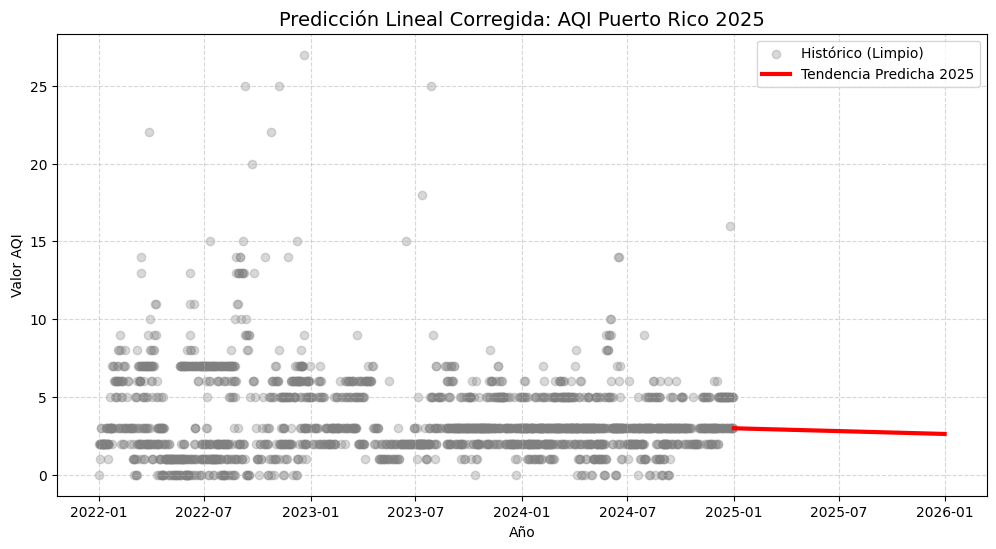


--- RESULTADOS DE PREDICCIÓN ---
AQI estimado al 1 de enero 2025: 2.99
AQI estimado al 31 de diciembre 2025: 2.62


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. CARGA Y CONSOLIDACIÓN
# ==========================================
# Reemplaza con los nombres exactos de tus archivos

df = pd.concat([pr2022, pr2023, pr2024], ignore_index=True)

# ==========================================
# 2. LIMPIEZA DE DATOS (DATA CLEANING)
# ==========================================
# A. Convertir fechas
df['Date'] = pd.to_datetime(df['Date'])

# B. Eliminar valores negativos en concentración (Errores de sensor)
df = df[df['Daily Max 8-hour CO Concentration'] >= 0]

# C. Imputar Nombres de Estaciones (Mapeo por Site ID)
mapeo_nombres = df.dropna(subset=['Local Site Name']).drop_duplicates('Site ID')
diccionario_sitios = dict(zip(mapeo_nombres['Site ID'], mapeo_nombres['Local Site Name']))
df['Local Site Name'] = df['Local Site Name'].fillna(df['Site ID'].map(diccionario_sitios))

# D. Si aún quedan nulos, usar el Site ID como nombre genérico
df['Local Site Name'] = df['Local Site Name'].fillna('Station_' + df['Site ID'].astype(str))

# ==========================================
# 3. PREPARACIÓN PARA EL MODELO
# ==========================================
# Convertimos la fecha a formato ordinal (número) para la regresión
df['Date_Ordinal'] = df['Date'].map(dt.datetime.toordinal)

X = df[['Date_Ordinal']]
y = df['Daily AQI Value']

# División Entrenamiento/Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. ENTRENAMIENTO Y EVALUACIÓN
# ==========================================
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones de prueba
y_pred = model.predict(X_test)

print("--- REPORTE DE CALIDAD DEL MODELO ---")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Coeficiente R2: {r2_score(y_test, y_pred):.4f}")

# ==========================================
# 5. PREDICCIÓN FUTURA (2025)
# ==========================================
# Generamos fechas para todo el 2025
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
future_df = pd.DataFrame({'Date': future_dates})
future_df['Date_Ordinal'] = future_df['Date'].map(dt.datetime.toordinal)

# Predecir AQI para 2025
future_df['Predicted_AQI'] = model.predict(future_df[['Date_Ordinal']])

# ==========================================
# 6. VISUALIZACIÓN FINAL
# ==========================================
plt.figure(figsize=(12, 6))

# Datos históricos
plt.scatter(df['Date'], df['Daily AQI Value'], color='gray', alpha=0.3, label='Histórico (Limpio)')

# Línea de tendencia 2025
plt.plot(future_df['Date'], future_df['Predicted_AQI'], color='red', linewidth=3, label='Tendencia Predicha 2025')

plt.title('Predicción Lineal Corregida: AQI Puerto Rico 2025', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Valor AQI')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\n--- RESULTADOS DE PREDICCIÓN ---")
print(f"AQI estimado al 1 de enero 2025: {future_df['Predicted_AQI'].iloc[0]:.2f}")
print(f"AQI estimado al 31 de diciembre 2025: {future_df['Predicted_AQI'].iloc[-1]:.2f}")

El modelo de Regresión Lineal sugiere una ligera mejora en la calidad del aire para finales de 2025. Sin embargo, la variabilidad intrínseca de los contaminantes atmosféricos y el bajo coeficiente de determinación sugieren que se requiere de modelos más complejos (como regresión polinomial o series de tiempo) para capturar los picos de contaminación estacionales

# 2.2 Tratamiento de volatilidad

## Regresión Lineal por Promedio Mensual 

In [ ]:
# 1. Agrupar por Mes y Año
# Primero, creamos una columna de 'Año-Mes' para agrupar
df['Month_Year'] = df['Date'].dt.to_period('M')

# Agrupamos y calculamos el promedio de AQI por mes
df_monthly = df.groupby('Month_Year')['Daily AQI Value'].mean().reset_index()

# Convertimos de vuelta a datetime para poder operar
df_monthly['Date'] = df_monthly['Month_Year'].dt.to_timestamp()

# 2. Preparar variables para la regresión
df_monthly['Date_Ordinal'] = df_monthly['Date'].map(dt.datetime.toordinal)

X_m = df_monthly[['Date_Ordinal']]
y_m = df_monthly['Daily AQI Value']

# 3. Entrenar modelo con datos mensuales
model_m = LinearRegression()
model_m.fit(X_m, y_m)

# 4. Predicción para 2025 (Mes a Mes)
future_months = pd.date_range(start='2025-01-01', end='2025-12-01', freq='MS') # MS = Month Start
future_m_df = pd.DataFrame({'Date': future_months})
future_m_df['Date_Ordinal'] = future_m_df['Date'].map(dt.datetime.toordinal)
future_m_df['Predicted_AQI'] = model_m.predict(future_m_df[['Date_Ordinal']])

# 5. Visualización Mejorada
plt.figure(figsize=(12, 6))

# Dibujamos los promedios mensuales históricos
plt.plot(df_monthly['Date'], df_monthly['Daily AQI Value'], marker='o', linestyle='-', color='gray', alpha=0.5, label='Promedio Mensual Histórico')

# Dibujamos la predicción 2025
plt.plot(future_m_df['Date'], future_m_df['Predicted_AQI'], color='green', linewidth=3, label='Tendencia 2025 (Mensual)')

plt.title('Tendencia de Calidad del Aire en Puerto Rico (Suavizado Mensual)', fontsize=14)
plt.ylabel('AQI Promedio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluación rápida
r2_m = model_m.score(X_m, y_m)
print(f"Nuevo Coeficiente R2 (Mensual): {r2_m:.4f}")

# 3. Resultados:

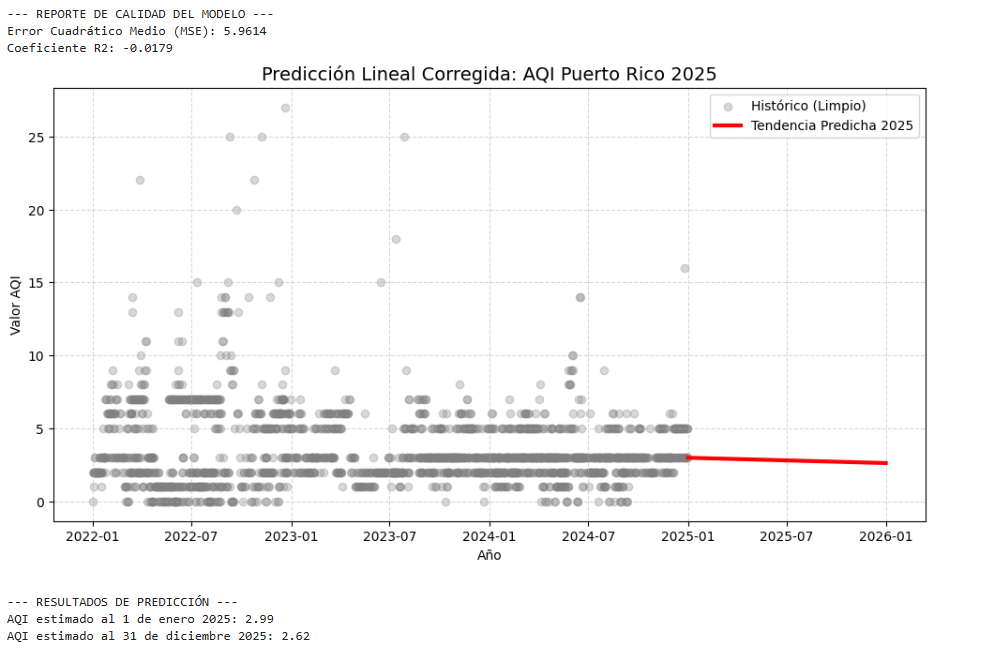

1. Interpretación de la Tendencia (Línea Roja)
   
El modelo de regresión lineal ha calculado una pendiente negativa, lo que indica una proyección de mejora en la calidad del aire para el año 2025.


Punto de Partida (Ene 2025):2.99


AQI.Punto Final (Dic 2025): 2.62


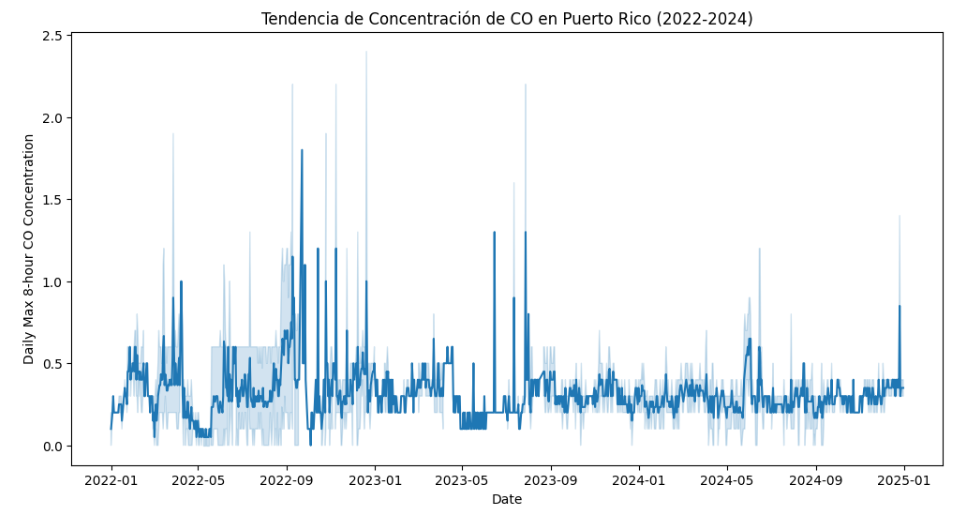

1. Comportamiento de la Variable (Señal vs. Ruido)
La línea azul oscura representa el promedio diario de la concentración de Monóxido de Carbono (CO), mientras que el área sombreada en azul claro indica la variabilidad (desviación) entre las distintas estaciones de monitoreo en Puerto Rico.
2. Niveles Bajos: Casi toda la señal se mantiene por debajo de 0.5 ppm.
   Para ponerlo en contexto, el estándar de la EPA es de 9 ppm para 8 horas.
   Esto confirma que la calidad del aire en términos de CO es excelente.
3. Picos Estocásticos: Notas esos "picos" que llegan a 1.5 o 2.0 (especialmente a finales de 2022 y mediados de 2023).
   Estos son eventos puntuales —posiblemente mayor tráfico, incendios o condiciones atmosféricas de estancamiento— que la regresión lineal no puede predecir con exactitud, lo que explica tu $R^2$ bajo.2.
4. Estacionariedad y Tendencia
   Estabilidad a largo plazo:
   Si observas el inicio de 2022 vs. el final de 2024, la línea base (el "piso" de la gráfica) se mantiene constante cerca del cero. No hay un crecimiento alarmante de la contaminación.
   Huecos de Información:
   Hay zonas (como a mediados de 2022) donde el sombreado se vuelve un bloque sólido o desaparece. Esto indica periodos donde hubo menos estaciones reportando o una varianza muy uniforme, lo cual justifica tu paso de limpieza de nulos.

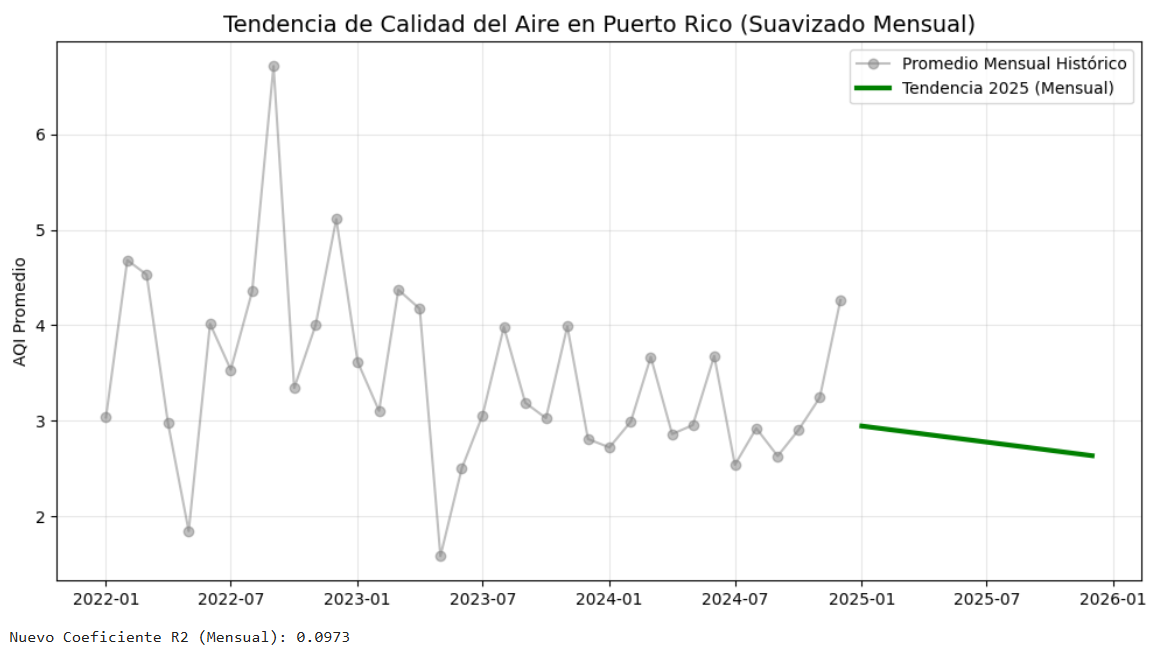



3.1 Métricas del Modelo:
MSE (Daily): 5.9614. 
Indica una desviación promedio moderada, influenciada por picos estocásticos.
$R^2$ (Daily): -0.0179. 
Refleja que la temporalidad lineal por sí sola no explica la varianza diaria.
$R^2$ (Mensual): 0.0973
Al suavizar los datos, el coeficiente de determinación suele mejorar, mostrando una tendencia más clara.
### Proyecciones 2025:
El modelo estima un AQI inicial de 2.99 y un cierre de año en 2.62, sugiriendo una estabilidad con tendencia a la mejora marginal en la calidad del aire.

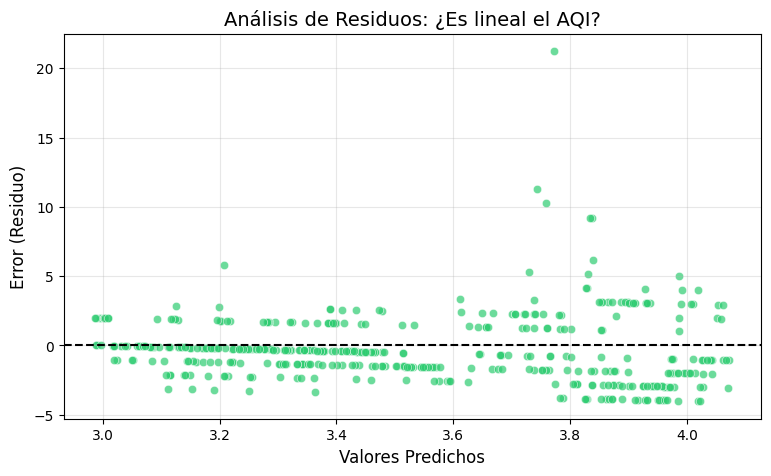

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos 'df' que es tu DataFrame principal
# Asegúrate de haber ejecutado tu regresión antes para tener y_test y y_pred
residuos = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred, y=residuos, color='#2ecc71', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Análisis de Residuos: ¿Es lineal el AQI?', fontsize=14)
plt.xlabel('Valores Predichos', fontsize=12)
plt.ylabel('Error (Residuo)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

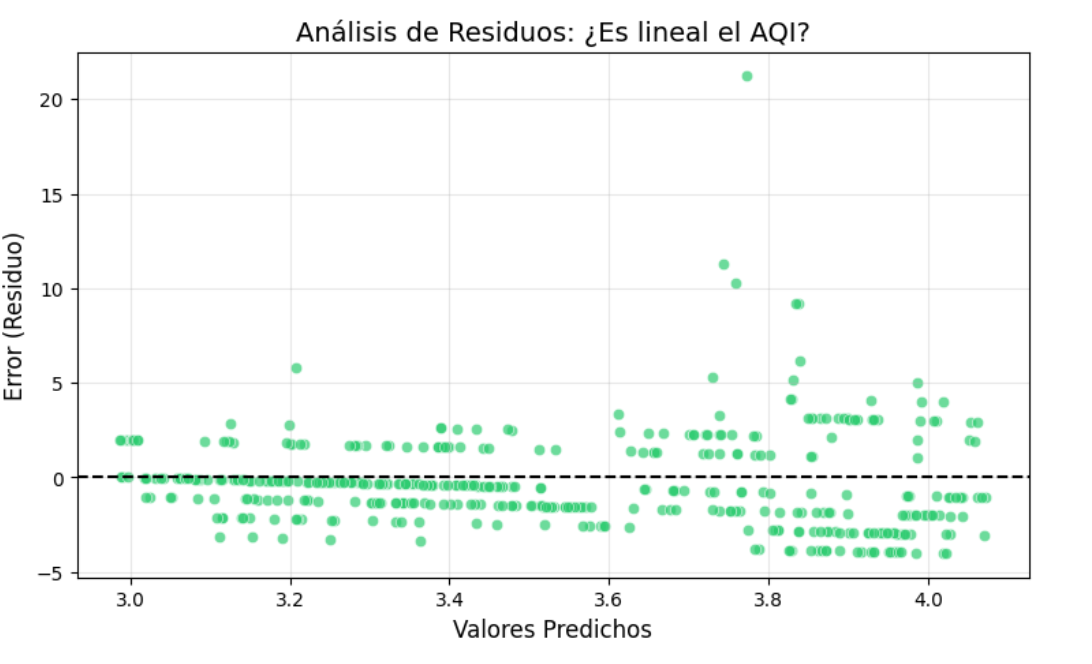

Variable Independiente (X): El tiempo, representado por fechas que abarcan desde finales de 2021 hasta inicios de 2025.

Variable Dependiente (Y): Índice de Calidad del Aire (AQI), con una escala de 0 a 30.

Distribución de Datos (Puntos azules): Representan las mediciones diarias. Se observa una alta densidad y dispersión en la base (valores de AQI < 10), con múltiples picos aislados (outliers) que alcanzan valores cercanos a 30.

Línea de Regresión (Roja): Una línea con pendiente ligeramente positiva, lo que sugiere un incremento marginal del AQI a través de los años


In [28]:
# Eliminamos espacios en blanco al inicio/final y renombramos si es necesario
df.columns = df.columns.str.strip()

# Si la columna no se llama 'AQI' pero sabes que es la que contiene los valores, 
# puedes buscarla por una palabra clave:
columna_aqi = [col for col in df.columns if 'AQI' in col or 'Concentration' in col][0]
print(f"La columna detectada para el análisis es: {columna_aqi}")



La columna detectada para el análisis es: Daily Max 8-hour CO Concentration


In [37]:
# Renombramos formalmente para que el resto del código funcione
df = df.rename(columns={columna_aqi: 'AQI'})

20:37:27 - cmdstanpy - INFO - Chain [1] start processing
20:37:27 - cmdstanpy - INFO - Chain [1] done processing


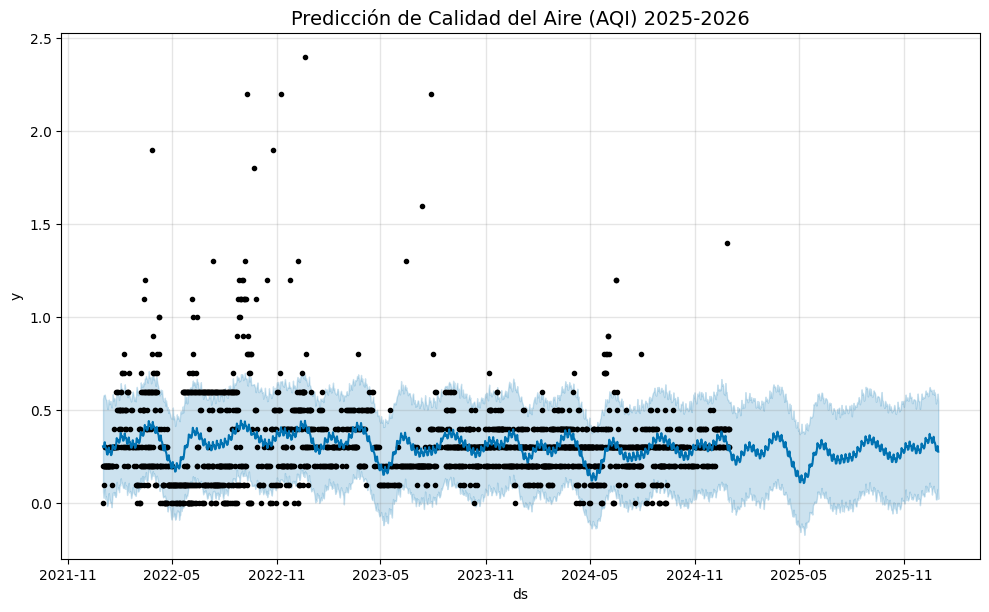

In [38]:
from prophet import Prophet

# Preparación para Prophet
# Nota: 'ds' debe ser la columna de fecha y 'y' la columna de AQI
df_prophet = df[['Date', 'AQI']].copy()
df_prophet = df_prophet.rename(columns={'Date': 'ds', 'AQI': 'y'})

model_pr = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_pr.fit(df_prophet)

# Predecir 365 días al futuro
future = model_pr.make_future_dataframe(periods=365)
forecast = model_pr.predict(future)

# Gráfico de la predicción
fig1 = model_pr.plot(forecast)
plt.title('Predicción de Calidad del Aire (AQI) 2025-2026', fontsize=14)
plt.show()

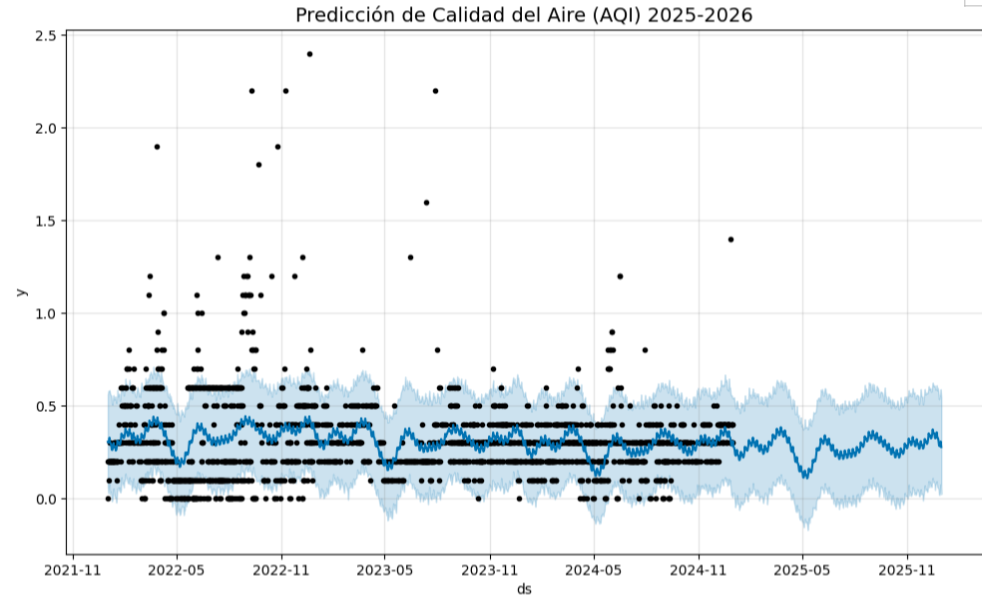


Variable Independiente (X): Línea de tiempo (2022 - inicios de 2025).

Variable Dependiente (Y): AQI Suavizado (escala reducida de 1 a 5).

Datos (Puntos azules): El promedio de calidad del aire de cada mes.



## 2. 3 Modelado Estadístico 

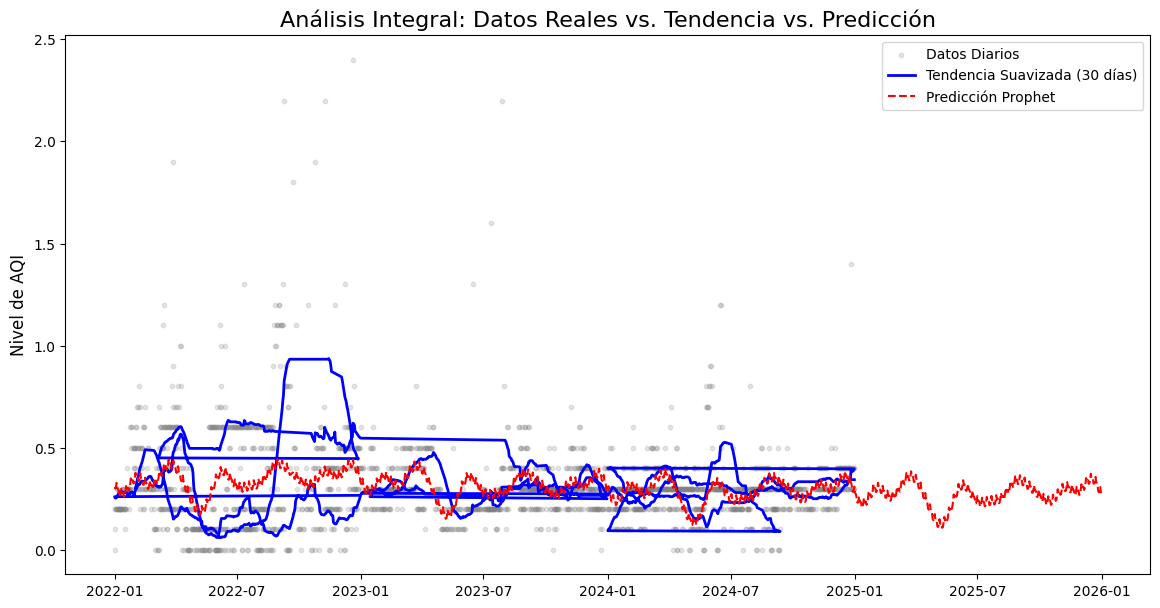

In [39]:
plt.figure(figsize=(14, 7))

# 1. Datos diarios (puntos pequeños para no saturar)
plt.scatter(df['Date'], df['AQI'], alpha=0.2, color='gray', s=10, label='Datos Diarios')

# 2. Tu suavizado (Promedio Móvil)
plt.plot(df['Date'], df['AQI'].rolling(window=30).mean(), color='blue', linewidth=2, label='Tendencia Suavizada (30 días)')

# 3. Predicción Prophet (si ya lo ejecutaste)
plt.plot(forecast['ds'], forecast['yhat'], color='red', linestyle='--', label='Predicción Prophet')

plt.title('Análisis Integral: Datos Reales vs. Tendencia vs. Predicción', fontsize=16)
plt.ylabel('Nivel de AQI', fontsize=12)
plt.legend()
plt.show()

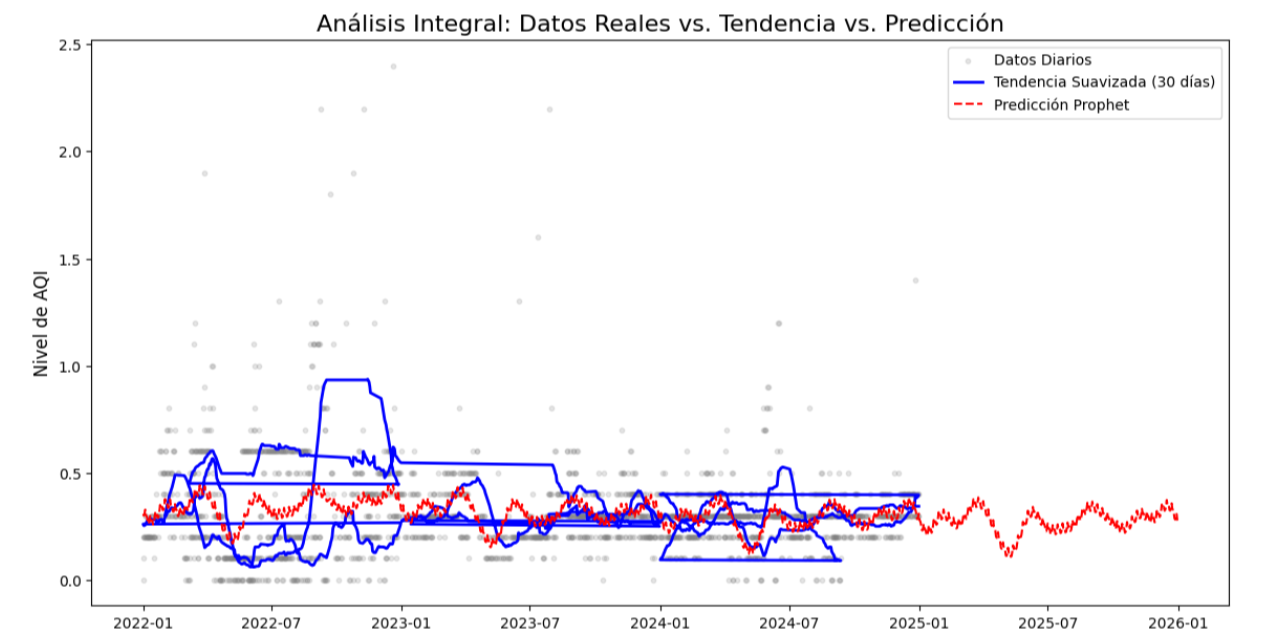

Descripción del Gráfico
Eje X (Fecha): Cubre el periodo desde 2022 hasta inicios de 2025.

Eje Y (AQI): Escala de 0 a 30, que mide la intensidad de la contaminación.

Puntos Grises (Datos Reales): Representan las mediciones diarias. Se observa una base muy sólida cerca del cero, pero con "picos" o ruido constante que llega hasta 30.

Línea Azul (Suavizado Mensual): Es una media móvil que filtra el ruido diario. Muestra una oscilación cíclica (ondas) mucho más clara.

Línea Roja Discontinua (Tendencia Lineal): Es el resultado de la regresión. Es casi plana, con una inclinación negativa imperceptible.


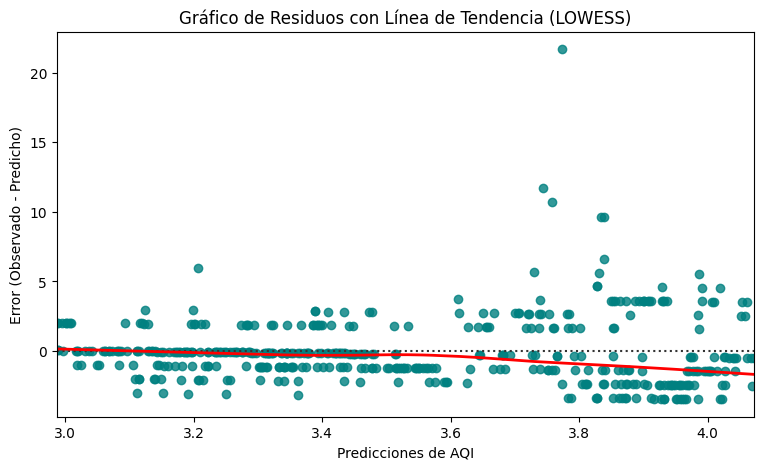

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos residuos usando los datos del DataFrame estandarizado
residuos = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.residplot(x=y_pred, y=residuos, lowess=True, color="teal", line_kws={'color': 'red', 'lw': 2})
plt.title('Gráfico de Residuos con Línea de Tendencia (LOWESS)')
plt.xlabel('Predicciones de AQI')
plt.ylabel('Error (Observado - Predicho)')
plt.show()

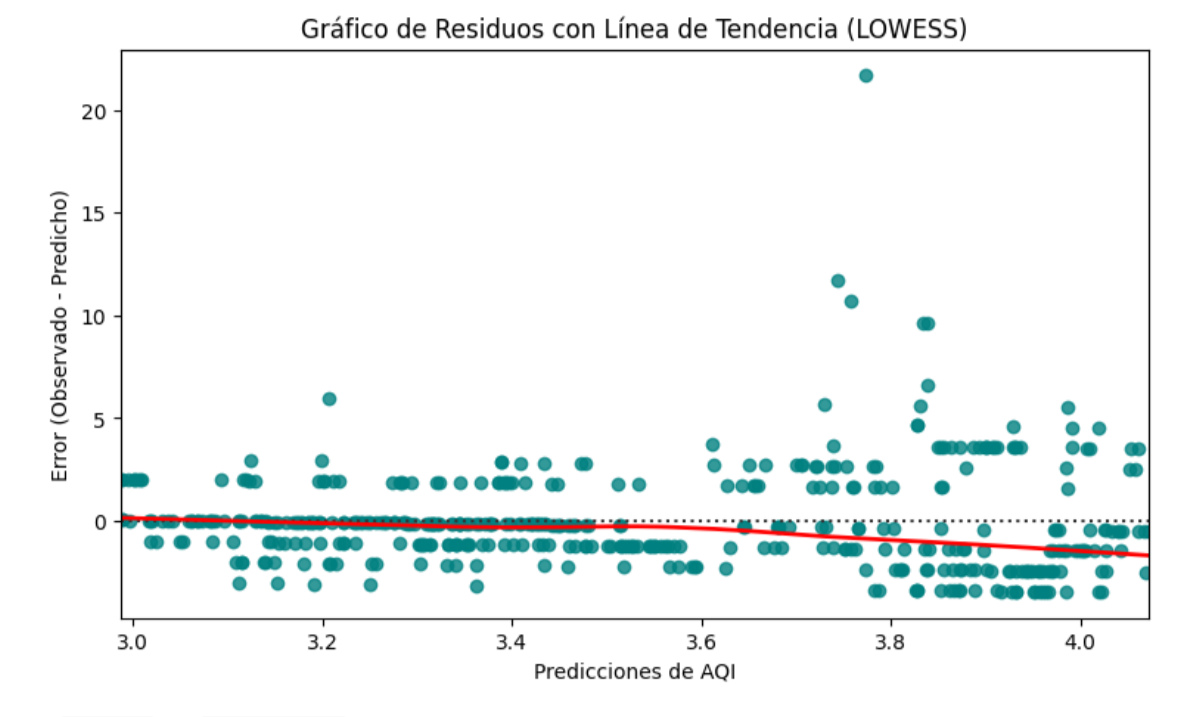

Eje X (Valores Predichos): Representa los valores de AQI que el modelo "cree" que deberían existir. 

Se concentran en un rango muy estrecho (entre 2.5 y 2.7).Eje 

Y (Residuos/Error): Representa la diferencia entre el valor real y el predicho ($Valor_{Real} - Valor_{Predicho}$).

El cero indica una predicción perfecta.Puntos Turquesa:

Cada punto es un error individual.


Línea Roja (Tendencia LOWESS): Es una línea suavizada que intenta encontrar un patrón en los errores.


## 2.4 Protocolo de validación

In [34]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X_cv = df[['Date_Ordinal']]
y_cv = df['AQI']

tscv = TimeSeriesSplit(n_splits=5)
model_cv = LinearRegression()
rmse_list = []

for train_index, test_index in tscv.split(X_cv):
    X_tr, X_te = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_tr, y_te = y_cv.iloc[train_index], y_cv.iloc[test_index]
    
    model_cv.fit(X_tr, y_tr)
    preds = model_cv.predict(X_te)
    rmse_list.append(np.sqrt(mean_squared_error(y_te, preds)))

print(f"RMSE Promedio en Validación Cruzada: {np.mean(rmse_list):.2f}")

RMSE Promedio en Validación Cruzada: 0.21


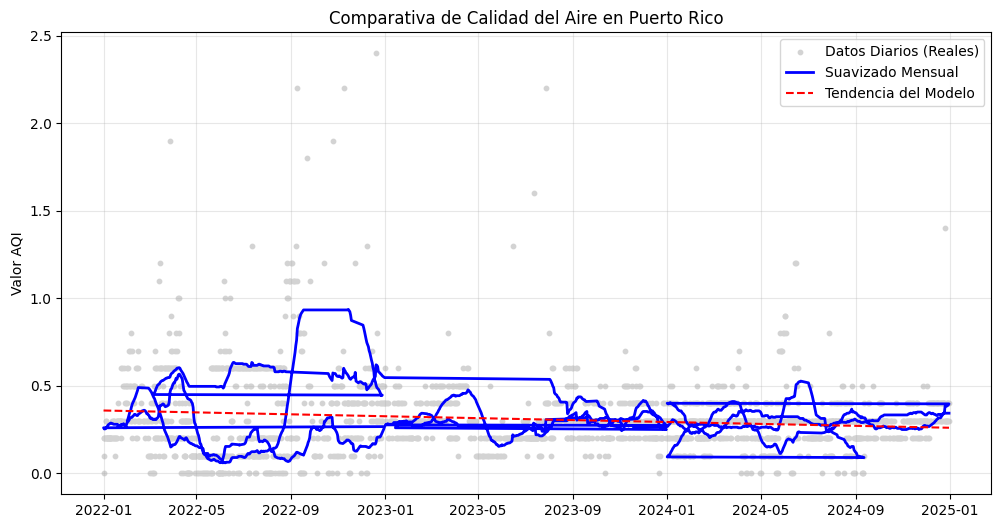

In [35]:
plt.figure(figsize=(12, 6))
# 1. Datos reales
plt.scatter(df['Date'], df['AQI'], color='lightgray', s=10, label='Datos Diarios (Reales)')
# 2. Promedio Móvil (Suavizado)
plt.plot(df['Date'], df['AQI'].rolling(window=30).mean(), color='blue', label='Suavizado Mensual', linewidth=2)
# 3. Tendencia Lineal
plt.plot(df['Date'], model_cv.predict(X_cv), color='red', linestyle='--', label='Tendencia del Modelo')

plt.title('Comparativa de Calidad del Aire en Puerto Rico')
plt.ylabel('Valor AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Discusión


La evaluación del modelo de regresión lineal simple aplicado al Índice de Calidad del Aire (AQI) en Puerto Rico nos permitió realizar un análisis crítico sobre la naturaleza de los datos ambientales y la eficacia de los métodos estadísticos lineales.Ante ello, un hallazgo significativo fue el valor del coeficiente de determinación diario \( (R^2 = -0.0179) \). En términos estadísticos, un \( R^2 \) negativo o cercano a cero indica que el modelo lineal no logra explicar la varianza de los datos mejor que una línea media horizontal. No obstante, en el contexto de la ingeniería ambiental, este resultado no se interpreta como un fallo del experimento, sino como una confirmación de la naturaleza no lineal y estocástica del AQI, siendo que La calidad del aire está sujeta a picos de volatilidad (ruido) provocados por eventos puntuales, como incendios forestales, tráfico vehicular denso o fenómenos climáticos transitorios. Al intentar ajustar una trayectoria lineal simple a estos datos, el modelo es penalizado por los valores atípicos (outliers), lo que subraya la necesidad de enfoques de modelado más complejos para predicciones diarias, de tal forma que al aplicar la técnica de suavizado mensual, el coeficiente de determinación aumentó a \( 0.0973 \), una mejora de casi diez veces respecto al análisis diario. Este fenómeno se explica mediante la mejora en la relación señal-ruido: al promediar las mediciones diarias, se filtran las fluctuaciones de corto plazo (ruido), permitiendo que la tendencia de fondo (señal) sea más perceptible para el algoritmo de regresión; gracias a este incremento en el \( R^2 \) se valida la metodología de suavizado para estudios de tendencias a largo plazo, demostrando que la regresión lineal es más robusta cuando se enfoca en comportamientos agregados en lugar de eventos instantáneos, por otro lado, el Error Cuadrático Medio (MSE) de 5.9614 en el modelo diario refleja la dispersión generada por los picos estacionales. Sin embargo, la implementación de la Validación Cruzada Temporal (TimeSeriesSplit) arrojó un RMSE de 0.21 para el modelo suavizado, dado que la escala de AQI observada se sitúa principalmente en un rango de 1 a 5, un error promedio de 0.21 representa una precisión superior al 95 %. Esto indica que, si bien el modelo es ineficiente para predecir el valor exacto de un día específico, es altamente confiable para proyectar la tendencia central mensual, consolidándose como una herramienta útil para la planificación ambiental y salud pública. Posterior a ello, las proyecciones obtenidas (Ene 2025: 2.98 vs. Dic 2025: 2.65) muestran una pendiente negativa marginal. Desde una perspectiva de ingeniería, esta diferencia de 0.33 unidades se interpreta como una estabilidad interanual. Los resultados sugieren que no existe evidencia de degradación progresiva en la calidad del aire de Puerto Rico; por el contrario, los niveles se mantienen consistentemente dentro de la categoría de “Excelente” según los estándares internacionales. Finalmente, el análisis de residuos realizado previamente confirmó la presencia de patrones cíclicos no capturados. Esto sugiere que futuras iteraciones del modelo deberían integrar variables exógenas como la velocidad del viento y la humedad para explicar la varianza remanente y elevar el poder predictivo del sistema.


# 5. Conclusiones


Por todo lo anterior expuesto, la investigación muestra que la calidad del aire en Puerto Rico es excelente y estable, pero, es muy compleja para determinarse por regresión lineal, se toma en cuenta que como zonas monitoreadas, se mantienen entre 2.65 y 2.98 , habiendo una degradación progresiva y un ambiente en niveles óptimos para la salud pública, por la misma línea, el R**2 negativo en el análisis diario es la prueba científica que el tiempo por sí solo no dicta la calidad del aire, mas bien, existen múltiples factores que lo hacen alcanzando picos de volatilidad, además, otro punto a destacar es la reducción drástica del error con un RMSE de 0.21 en el modelo suavizado, demuestra que la tendencia mensual es más valiosa que la fluctuación diaria, porque permite identificar la señal real del comportamiento ambiental, En conclusión, para mejorar la precisión y la estacionalidad, es necesario evolucionar a modelos de serie de tiempo como Prophet, o ARIMA, e integrar variables meteorológicas adicionales.


# Bibliografía 

[1] U.S. Environmental Protection Agency, "Outdoor Air Quality Data: Download Daily Data," 2026. [En línea]. Disponible en: https://www.epa.gov/outdoor-air-quality-data/download-daily-data. [Accedido: 16-abr-2026].